In [1]:
# ── 라이브러리 체크 ──────────────────────────────────────────────────────
import importlib, subprocess, sys
_NEEDED = ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn',
           'xgboost','lightgbm','optuna','joblib']
_missing = []
for pkg in _NEEDED:
    mod = pkg.replace('-', '_')
    try:
        importlib.import_module('sklearn' if pkg == 'scikit-learn' else mod)
    except ImportError:
        _missing.append(pkg)
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_missing])
print(f'✅ 라이브러리 준비 완료 (설치: {_missing or "없음"})')

✅ 라이브러리 준비 완료 (설치: 없음)


In [2]:
import os, warnings, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, GroupKFold, learning_curve
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU 자동 감지 ─────────────────────────────────────────────────────────
def detect_gpu():
    try:
        out = subprocess.check_output(['nvidia-smi'], stderr=subprocess.DEVNULL)
        return True
    except Exception:
        return False

HAS_GPU    = detect_gpu()
XGB_DEVICE = 'cuda' if HAS_GPU else 'cpu'
LGB_DEVICE = 'gpu'  if HAS_GPU else 'cpu'
print(f'✅ GPU 감지: {HAS_GPU} | XGB={XGB_DEVICE} | LGBM={LGB_DEVICE}')

✅ GPU 감지: True | XGB=cuda | LGBM=gpu


In [3]:
# ── 컬럼 정의 ─────────────────────────────────────────────────────────────
RAW_COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP  = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']
print('✅ 컬럼 정의 완료')

✅ 컬럼 정의 완료


In [4]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # ── ★ Subset 선택 (FD001 / FD002 / FD003 / FD004) ──
    'subset': 'FD001',

    # ── 센서 수동 제거 ──
    'manual_remove_sensors': ['s_1', 's_5', 's_6','s_10', 's_16', 's_18', 's_19'],
    # FD001 : 's_1', 's_5', 's_6','s_10', 's_16', 's_18', 's_19'
    # FD002 : 's_16' 
    # FD003,4 : 's_1', 's_5', 's_6','s_16', 's_18', 's_19'


    # ── 클러스터링 (FD002/FD004 에서만 사용) ──
    'n_clusters': 6,

    # ── RUL Cap ──
    'rul_cap': 120,

    # ── Gaussian sigma (None / 0 = skip) ──
    'gaussian_sigma': 1,
    'smoothing_method': 'gaussian',  # 'gaussian' / 'causal_ema'

    # ── 정규화 방식 ('minmax' / 'standard') ──
    'normalize': 'minmax',

    # ── 시계열 파생변수 ──
    'rolling_means':[15, 80, 110],
    'diffs':        [20,60,100],
    'lags':         [20,70,120],
    'rolling_stds': [30,70,90],
    'emas':         [120],
}

CONST_THR    = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

# ── 분기 플래그 자동 결정 ──
_VALID_SUBSETS = {'FD001', 'FD002', 'FD003', 'FD004'}
assert CONFIG['subset'] in _VALID_SUBSETS, f"subset must be one of {_VALID_SUBSETS}"
USE_CLUSTERING = CONFIG['subset'] in ('FD002', 'FD004')
EFFECTIVE_K    = CONFIG['n_clusters'] if USE_CLUSTERING else 1

print('✅ CONFIG 로드 완료')
print(f"   ► Subset         : {CONFIG['subset']}")
print(f"   ► Use clustering : {USE_CLUSTERING}  (effective k = {EFFECTIVE_K})")
for k, v in CONFIG.items():
    if k == 'subset': continue
    print(f'   {k:24s}: {v}')
print(f'\n   CONST_THR={CONST_THR} | VALID_RATIO={VALID_RATIO} | RANDOM_STATE={RANDOM_STATE}')


✅ CONFIG 로드 완료
   ► Subset         : FD001
   ► Use clustering : False  (effective k = 1)
   manual_remove_sensors   : ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
   n_clusters              : 6
   rul_cap                 : 120
   gaussian_sigma          : 1
   smoothing_method        : gaussian
   normalize               : minmax
   rolling_means           : [15, 80, 110]
   diffs                   : [20, 60, 100]
   lags                    : [20, 70, 120]
   rolling_stds            : [30, 70, 90]
   emas                    : [120]

   CONST_THR=0.01 | VALID_RATIO=0.2 | RANDOM_STATE=42


In [5]:
SUBSET = CONFIG['subset']  # e.g. 'FD001'

DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, f'train_{SUBSET}.txt')):
        DATA_DIR = c; break
else:
    print(f'⚠️ CMAPSSData 폴더를 찾지 못했습니다. 현재 위치: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_{SUBSET}.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_{SUBSET}.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_{SUBSET}.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ {SUBSET} 로딩 완료')
print(f'   Train : {train_raw.shape}  | 엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   | 엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
train_raw.head(3)


✅ FD001 로딩 완료
   Train : (20631, 26)  | 엔진 100대
   Test  : (13096, 26)   | 엔진 100대
   RUL   : (100, 1)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


In [6]:
# ============================================================
# 🔧 파이프라인 함수 (FD001~FD004 통합 — USE_CLUSTERING 분기)
# ============================================================

def filter_useful_sensors(sensor_cols, manual_remove):
    """수동 제거 리스트만 적용 — 자동 제거 없음"""
    remove = sorted(list(set(manual_remove or [])))
    useful = [s for s in sensor_cols if s not in remove]
    useful = sorted(useful, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    return useful, remove


def cluster_op_conditions(train_df, test_df, op_cols, n_clusters,
                          random_state=RANDOM_STATE):
    """FD002/FD004: setting_1/2/3 MinMax → KMeans(k=n_clusters)"""
    op_scaler  = MinMaxScaler()
    op_train_z = op_scaler.fit_transform(train_df[op_cols])
    op_test_z  = op_scaler.transform(test_df[op_cols])

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state,
                    n_init=20, max_iter=300)
    kmeans.fit(op_train_z)

    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = kmeans.labels_
    test_df['op_cluster']  = kmeans.predict(op_test_z)
    return train_df, test_df, op_scaler, kmeans


def assign_dummy_cluster(train_df, test_df):
    """FD001/FD003: 클러스터링 스킵 — op_cluster=0 단일 그룹 부여"""
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = 0
    test_df['op_cluster']  = 0
    return train_df, test_df


def add_piecewise_rul(df, cap):
    """엔진별 RUL = max(cycle) - cycle, cap 적용"""
    df  = df.copy()
    mc  = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df  = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_smoothing(df, features, sigma, use_clustering):
    """(unit × cluster) 또는 (unit) 단위 가우시안 스무딩"""
    df  = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    grp_cols = ['unit_nr','op_cluster'] if use_clustering else ['unit_nr']
    grp = df.groupby(grp_cols)
    def _smooth(s):
        arr = s.values.astype(np.float32)
        if len(arr) > 1:
            return pd.Series(gaussian_filter1d(arr, sigma=sigma, mode='nearest'),
                             index=s.index)
        return s
    for col in features:
        df[col] = grp[col].transform(_smooth)
    return df


def apply_causal_ema_smoothing(df, features, sigma, use_clustering):
    """[누수 없음] (unit × cluster) 또는 (unit) 단위 causal EMA. span=2σ+1"""
    span = 2 * sigma + 1
    df  = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    grp_cols = ['unit_nr','op_cluster'] if use_clustering else ['unit_nr']
    grp = df.groupby(grp_cols)
    for col in features:
        df[col] = grp[col].transform(
            lambda x: x.ewm(span=span, adjust=False).mean())
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진 단위 random split — 누수 방지"""
    units = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio,
                                    random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


def normalize_features(sub, val, test, features, n_clusters, method, use_clustering):
    """USE_CLUSTERING 분기:
    - True  : 클러스터별 scaler (FD002/FD004)
    - False : 전체 sub-train fit, val/test transform (FD001/FD003)
    """
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    sub  = sub.copy();  val  = val.copy();  test = test.copy()
    scalers = {}

    if not use_clustering:
        # ── 전체 fit (FD001/FD003) ──
        scaler = ScalerCls()
        sub[features]  = scaler.fit_transform(sub[features])
        val[features]  = scaler.transform(val[features])
        test[features] = scaler.transform(test[features])
        scalers[0] = scaler
        return sub, val, test, scalers

    # ── 클러스터별 fit (FD002/FD004) ──
    for c in range(n_clusters):
        mask_s = sub['op_cluster'] == c
        if mask_s.sum() == 0:
            scaler_c = ScalerCls()
            scaler_c.fit(sub[features])
        else:
            scaler_c = ScalerCls()
            sub.loc[mask_s, features] = scaler_c.fit_transform(sub.loc[mask_s, features])
        scalers[c] = scaler_c

    for df_target in (val, test):
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0:
                df_target.loc[mask, features] = scalers[c].transform(
                    df_target.loc[mask, features])
    return sub, val, test, scalers


def add_temporal_features(df, sensor_cols,
                          lags, diffs, rolls, roll_stds, emas):
    """unit 단위 시계열 파생변수 (subset 공통 — 기존 FD004 코드와 동일하게 unit만 사용)"""
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)

    for s in sensor_cols:
        grp = df.groupby(['unit_nr'])[s]
        for lag in (lags or []):
            df[f'{s}_lag{lag}']    = grp.shift(lag)
        for d in (diffs or []):
            df[f'{s}_diff{d}']     = grp.diff(d)
        for r in (rolls or []):
            df[f'{s}_roll{r}']     = grp.transform(
                lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}']  = grp.transform(
                lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []):
            df[f'{s}_ema{span}']   = grp.transform(
                lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)


def add_ohe_cluster(df, n_clusters):
    """FD002/FD004: op_cluster 원핫인코딩"""
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    out = pd.concat([df.reset_index(drop=True),
                     ohe[ohe_cols].reset_index(drop=True)], axis=1)
    return out, ohe_cols


def run_pipeline(train_raw, test_raw, cfg):
    """FD001~FD004 통합 전처리 파이프라인 (USE_CLUSTERING 분기)"""
    use_cluster = cfg['subset'] in ('FD002', 'FD004')
    eff_k       = cfg['n_clusters'] if use_cluster else 1
    print(f"\n▶ Subset = {cfg['subset']} | Clustering = {use_cluster} (k={eff_k})\n")

    # ── 1. 센서 필터링 ─────────────────────────────────────────────
    useful, removed = filter_useful_sensors(SENSOR_COLS, cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 유지 {len(useful)}개 / 제거 {len(removed)}개  {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1  = train_raw[keep].copy()
    te1  = test_raw[keep].copy()

    # ── 2. (분기) 운전조건 클러스터링 ────────────────────────────────
    if use_cluster:
        tr2, te2, op_scaler, kmeans = cluster_op_conditions(
            tr1, te1, OP_COLS, cfg['n_clusters'])
        print(f'[2] 운전조건 KMeans(k={cfg["n_clusters"]}) 클러스터링 완료')
        print(f'    train 클러스터 분포: {tr2["op_cluster"].value_counts().sort_index().to_dict()}')
    else:
        tr2, te2 = assign_dummy_cluster(tr1, te1)
        op_scaler, kmeans = None, None
        print('[2] 클러스터링 스킵 — op_cluster=0 단일 그룹')

    # ── 3. Piecewise RUL ──────────────────────────────────────────
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    te3 = te2.copy()
    print(f'[3] Piecewise RUL 적용 (cap={cfg["rul_cap"]})')

    # ── 4. (분기) Smoothing ───────────────────────────────────────
    method = cfg.get('smoothing_method', 'gaussian')
    sigma  = cfg.get('gaussian_sigma', 0)
    grp_label = '(unit × cluster)' if use_cluster else '(unit)'

    if sigma > 0 and method == 'gaussian':
        tr4 = apply_gaussian_smoothing(tr3, useful, sigma, use_cluster)
        te4 = apply_gaussian_smoothing(te3, useful, sigma, use_cluster)
        print(f'[4] Gaussian σ={sigma} {grp_label}')
    elif sigma > 0 and method == 'causal_ema':
        tr4 = apply_causal_ema_smoothing(tr3, useful, sigma, use_cluster)
        te4 = apply_causal_ema_smoothing(te3, useful, sigma, use_cluster)
        print(f'[4] Causal EMA span={2*sigma+1} {grp_label}')
    else:
        tr4, te4 = tr3, te3
        print('[4] Smoothing skip')

    # ── 5. 엔진 단위 split ────────────────────────────────────────
    sub5, val5, sub_units, val_units = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    test5 = te4.copy()
    print(f'[5] 데이터 분할: sub={len(sub_units)}대 / val={len(val_units)}대')

    # ── 6. (분기) 정규화 ──────────────────────────────────────────
    sub6, val6, test6, scalers = normalize_features(
        sub5, val5, test5, useful, eff_k, cfg['normalize'], use_cluster)
    norm_label = f'클러스터별 ({len(scalers)}개)' if use_cluster else '전체 단일'
    print(f'[6] {cfg["normalize"]} 정규화 완료 — {norm_label}')

    # ── 7. 시계열 파생변수 (unit 단위 공통) ────────────────────────
    sub7  = add_temporal_features(sub6,  useful, cfg['lags'], cfg['diffs'],
                                  cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    val7  = add_temporal_features(val6,  useful, cfg['lags'], cfg['diffs'],
                                  cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    test7 = add_temporal_features(test6, useful, cfg['lags'], cfg['diffs'],
                                  cfg['rolling_means'], cfg['rolling_stds'], cfg['emas'])
    print(f'[7] 시계열 파생변수 생성 완료 (unit 단위)')

    # ── 8. (분기) OHE 클러스터 ────────────────────────────────────
    if use_cluster:
        sub8,  ohe_cols = add_ohe_cluster(sub7,  eff_k)
        val8,  _        = add_ohe_cluster(val7,  eff_k)
        test8, _        = add_ohe_cluster(test7, eff_k)
        print(f'[8] OHE 추가: {ohe_cols}')
    else:
        sub8, val8, test8 = sub7, val7, test7
        ohe_cols = []
        print('[8] OHE 스킵 (단일 클러스터)')

    # ── ML 피처 정의 ─────────────────────────────────────────────
    EXCLUDE = set(ID_COLS + OP_COLS + ['RUL','RUL_raw','op_cluster'])
    ml_features = [c for c in sub8.columns if c not in EXCLUDE]
    print(f'[✓] ML features={len(ml_features)}개 (센서파생 + OHE {len(ohe_cols)}개)')

    return {
        'subtrain_ml': sub8, 'valid_ml': val8, 'test_ml': test8,
        'ml_features': ml_features,
        'useful_sensors': useful, 'ohe_cols': ohe_cols,
        'op_scaler': op_scaler, 'kmeans': kmeans, 'scalers': scalers,
        'use_clustering': use_cluster,
    }

print('✅ 파이프라인 함수 정의 완료 (FD001~FD004 통합)')


✅ 파이프라인 함수 정의 완료 (FD001~FD004 통합)


In [7]:
data        = run_pipeline(train_raw, test_raw, CONFIG)

train_ml    = data['subtrain_ml'].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
valid_ml    = data['valid_ml'   ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
test_ml     = data['test_ml'    ].sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
ML_FEATURES = data['ml_features']
OHE_COLS    = data['ohe_cols']

# Test 평가: 엔진별 마지막 사이클만 (RUL_FD00*.txt 와 비교)
test_last   = test_ml.groupby('unit_nr').last().reset_index()

X_train, y_train = train_ml[ML_FEATURES], train_ml['RUL']
X_val,   y_val   = valid_ml[ML_FEATURES], valid_ml['RUL']
X_test           = test_last[ML_FEATURES]
y_test           = rul_df['RUL'].values

print(f'\n[실행 결과]')
print(f'  Sub-train : {train_ml.shape}')
print(f'  Validation: {valid_ml.shape}')
print(f'  Test      : {test_ml.shape}  (test_last: {test_last.shape})')
print(f'  ML 피처 수: {len(ML_FEATURES)}개  (OHE {len(OHE_COLS)}개 포함)')
print(f'  주요 피처 : {ML_FEATURES[:6]} ... {OHE_COLS}')


▶ Subset = FD001 | Clustering = False (k=1)

[1] 센서 필터링: 유지 14개 / 제거 7개  ['s_1', 's_10', 's_16', 's_18', 's_19', 's_5', 's_6']
[2] 클러스터링 스킵 — op_cluster=0 단일 그룹
[3] Piecewise RUL 적용 (cap=120)
[4] Gaussian σ=1 (unit)
[5] 데이터 분할: sub=80대 / val=20대
[6] minmax 정규화 완료 — 전체 단일
[7] 시계열 파생변수 생성 완료 (unit 단위)
[8] OHE 스킵 (단일 클러스터)
[✓] ML features=196개 (센서파생 + OHE 0개)

[실행 결과]
  Sub-train : (16561, 204)
  Validation: (4070, 204)
  Test      : (13096, 202)  (test_last: (100, 202))
  ML 피처 수: 196개  (OHE 0개 포함)
  주요 피처 : ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9'] ... []


In [8]:
# ── NASA Score (예측이 늦으면 패널티 ↑) ──────────────────────────────────
def calculate_nasa_score(y_true, y_pred):
    d     = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(score))

def get_metrics(y_true, y_pred, cap=CONFIG['rul_cap']):
    pred = np.clip(np.asarray(y_pred, dtype=float), 0, cap)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, pred))),
        'MAE'       : float(mean_absolute_error(y_true, pred)),
        'R2'        : float(r2_score(y_true, pred)),
        'NASA_Score': calculate_nasa_score(y_true, pred),
    }

# ── 통합 시각화 함수 (2×3 — 6 plots) ──────────────────────────────────────
def evaluate_full_pipeline(model, model_name, is_tree=False, is_boosting=False,
                           eval_results=None):
    pred_train = model.predict(X_train)
    pred_val   = model.predict(X_val)
    pred_test  = model.predict(X_test)

    res = {
        'Train': get_metrics(y_train, pred_train),
        'Valid': get_metrics(y_val,   pred_val),
        'Test' : get_metrics(y_test,  pred_test),
    }

    print(f"\n{'='*55}\n 🏆 {model_name} 평가 결과 ({CONFIG['subset']})\n{'='*55}")
    for split, m in res.items():
        print(f" [{split:5s}] RMSE={m['RMSE']:.4f} | MAE={m['MAE']:.4f} | "
              f"R2={m['R2']:.4f} | NASA={m['NASA_Score']:.1f}")

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f"{model_name} — 전체 평가 ({CONFIG['subset']})", fontsize=14, fontweight='bold')
    plt.subplots_adjust(hspace=0.35)

    # ① Learning / Loss Curve
    ax1 = axes[0, 0]
    if is_boosting and eval_results:
        ax1.plot(eval_results['train'], label='Train RMSE')
        ax1.plot(eval_results['valid'], label='Valid RMSE')
        ax1.set_xlabel('Iterations')
    else:
        sizes, t_sc, v_sc = learning_curve(
            model, X_train, y_train, cv=3,
            scoring='neg_root_mean_squared_error',
            train_sizes=np.linspace(0.2, 1.0, 5))
        ax1.plot(sizes, -np.mean(t_sc, axis=1), 'o-', label='Train RMSE')
        ax1.plot(sizes, -np.mean(v_sc, axis=1), 'o-', label='Valid RMSE')
        ax1.set_xlabel('Training Samples')
    ax1.set_title('① Learning / Loss Curve'); ax1.legend(); ax1.grid(True)

    # ② Residual Plot (Validation)
    axes[0, 1].scatter(pred_val, y_val - pred_val, alpha=0.3, color='orange', s=8)
    axes[0, 1].axhline(0, color='red', ls='--')
    axes[0, 1].set_title('② Residual Plot (Validation)')
    axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Residual')

    # ③ Feature Importance / Coefficient
    ax3 = axes[0, 2]
    imp = model.feature_importances_ if is_tree else np.abs(model.coef_)
    n_features = len(imp)
    top_n = min(n_features, 15)
    idx = np.argsort(imp)[-top_n:]
    ax3.barh(range(top_n), imp[idx], color='teal')
    ax3.set_yticks(range(top_n))
    ax3.set_yticklabels(np.array(ML_FEATURES)[idx], fontsize=8)
    ax3.set_title(f'③ Top-{top_n} Feature Importance')

    # ④ Target vs Prediction Distribution (Validation)
    sns.kdeplot(y_val,    label='Actual', ax=axes[1, 0], fill=True)
    sns.kdeplot(pred_val, label='Pred',   ax=axes[1, 0], fill=True)
    axes[1, 0].set_title('④ RUL 분포 비교 (Validation)'); axes[1, 0].legend()

    # ⑤ Feature Weight Histogram
    axes[1, 1].hist(imp, bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('⑤ Feature Weight Histogram')

    # ⑥ Test — Actual vs Predicted Line
    ax6 = axes[1, 2]
    ax6.plot(y_test.values if hasattr(y_test, 'values') else y_test,
             label='Actual RUL', color='black', lw=1.5)
    ax6.plot(pred_test, label='Predicted RUL', color='red', ls='--', alpha=0.8)
    ax6.set_title('⑥ Test: Actual vs Predicted')
    ax6.set_xlabel('Engine Index'); ax6.set_ylabel('RUL')
    ax6.legend(); ax6.grid(True)

    plt.tight_layout(); plt.show()
    return res

print('✅ 평가 & 시각화 함수 정의 완료')

✅ 평가 & 시각화 함수 정의 완료


In [9]:
##### 추가
# ── Test metric 함수 ─────────────────────────────────────────────
def get_test_metrics(model, *, cap=CONFIG['rul_cap']):
    pred_test = model.predict(X_test)
    m = get_metrics(y_test, pred_test, cap=cap)
    return m['RMSE'], m['NASA_Score']


# ── 실행 (순서 고정) ─────────────────────────────────────────────
results = []

# 1. Ridge
model = Ridge(alpha=1.0, solver='auto', max_iter=2000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
results.append(['Ridge', *get_test_metrics(model)])

# 2. Lasso
model = Lasso(alpha=0.1, max_iter=2000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
results.append(['Lasso', *get_test_metrics(model)])

# 3. ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
results.append(['ElasticNet', *get_test_metrics(model)])

# 4. RandomForest
model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
results.append(['RandomForest', *get_test_metrics(model)])

# 5. LightGBM
model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    device=LGB_DEVICE,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train),(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)]
)
results.append(['LightGBM', *get_test_metrics(model)])

# 6. XGBoost
model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method='hist', device=XGB_DEVICE,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train),(X_val, y_val)],
    verbose=False
)
results.append(['XGBoost', *get_test_metrics(model)])


# ── 결과 정리 ───────────────────────────────────────────────────
df_results = pd.DataFrame(results, columns=['Model', 'Test RMSE', 'Test NASA'])
pd.options.display.float_format = '{:.4f}'.format

print(df_results)                 # 순서 그대로 보기
print('\n[RMSE 기준 정렬]')
print(df_results.sort_values('Test RMSE'))

          Model  Test RMSE  Test NASA
0         Ridge    16.0839   348.1774
1         Lasso    16.8896   386.3224
2    ElasticNet    18.2145   473.1338
3  RandomForest    13.3902   229.6397
4      LightGBM    13.5175   237.1307
5       XGBoost    13.6103   239.0007

[RMSE 기준 정렬]
          Model  Test RMSE  Test NASA
3  RandomForest    13.3902   229.6397
4      LightGBM    13.5175   237.1307
5       XGBoost    13.6103   239.0007
0         Ridge    16.0839   348.1774
1         Lasso    16.8896   386.3224
2    ElasticNet    18.2145   473.1338



 🏆 Ridge 평가 결과 (FD001)
 [Train] RMSE=11.2867 | MAE=8.2970 | R2=0.9197 | NASA=30013.1
 [Valid] RMSE=11.3899 | MAE=8.3945 | R2=0.9186 | NASA=7451.6
 [Test ] RMSE=16.0839 | MAE=12.4335 | R2=0.8502 | NASA=348.2


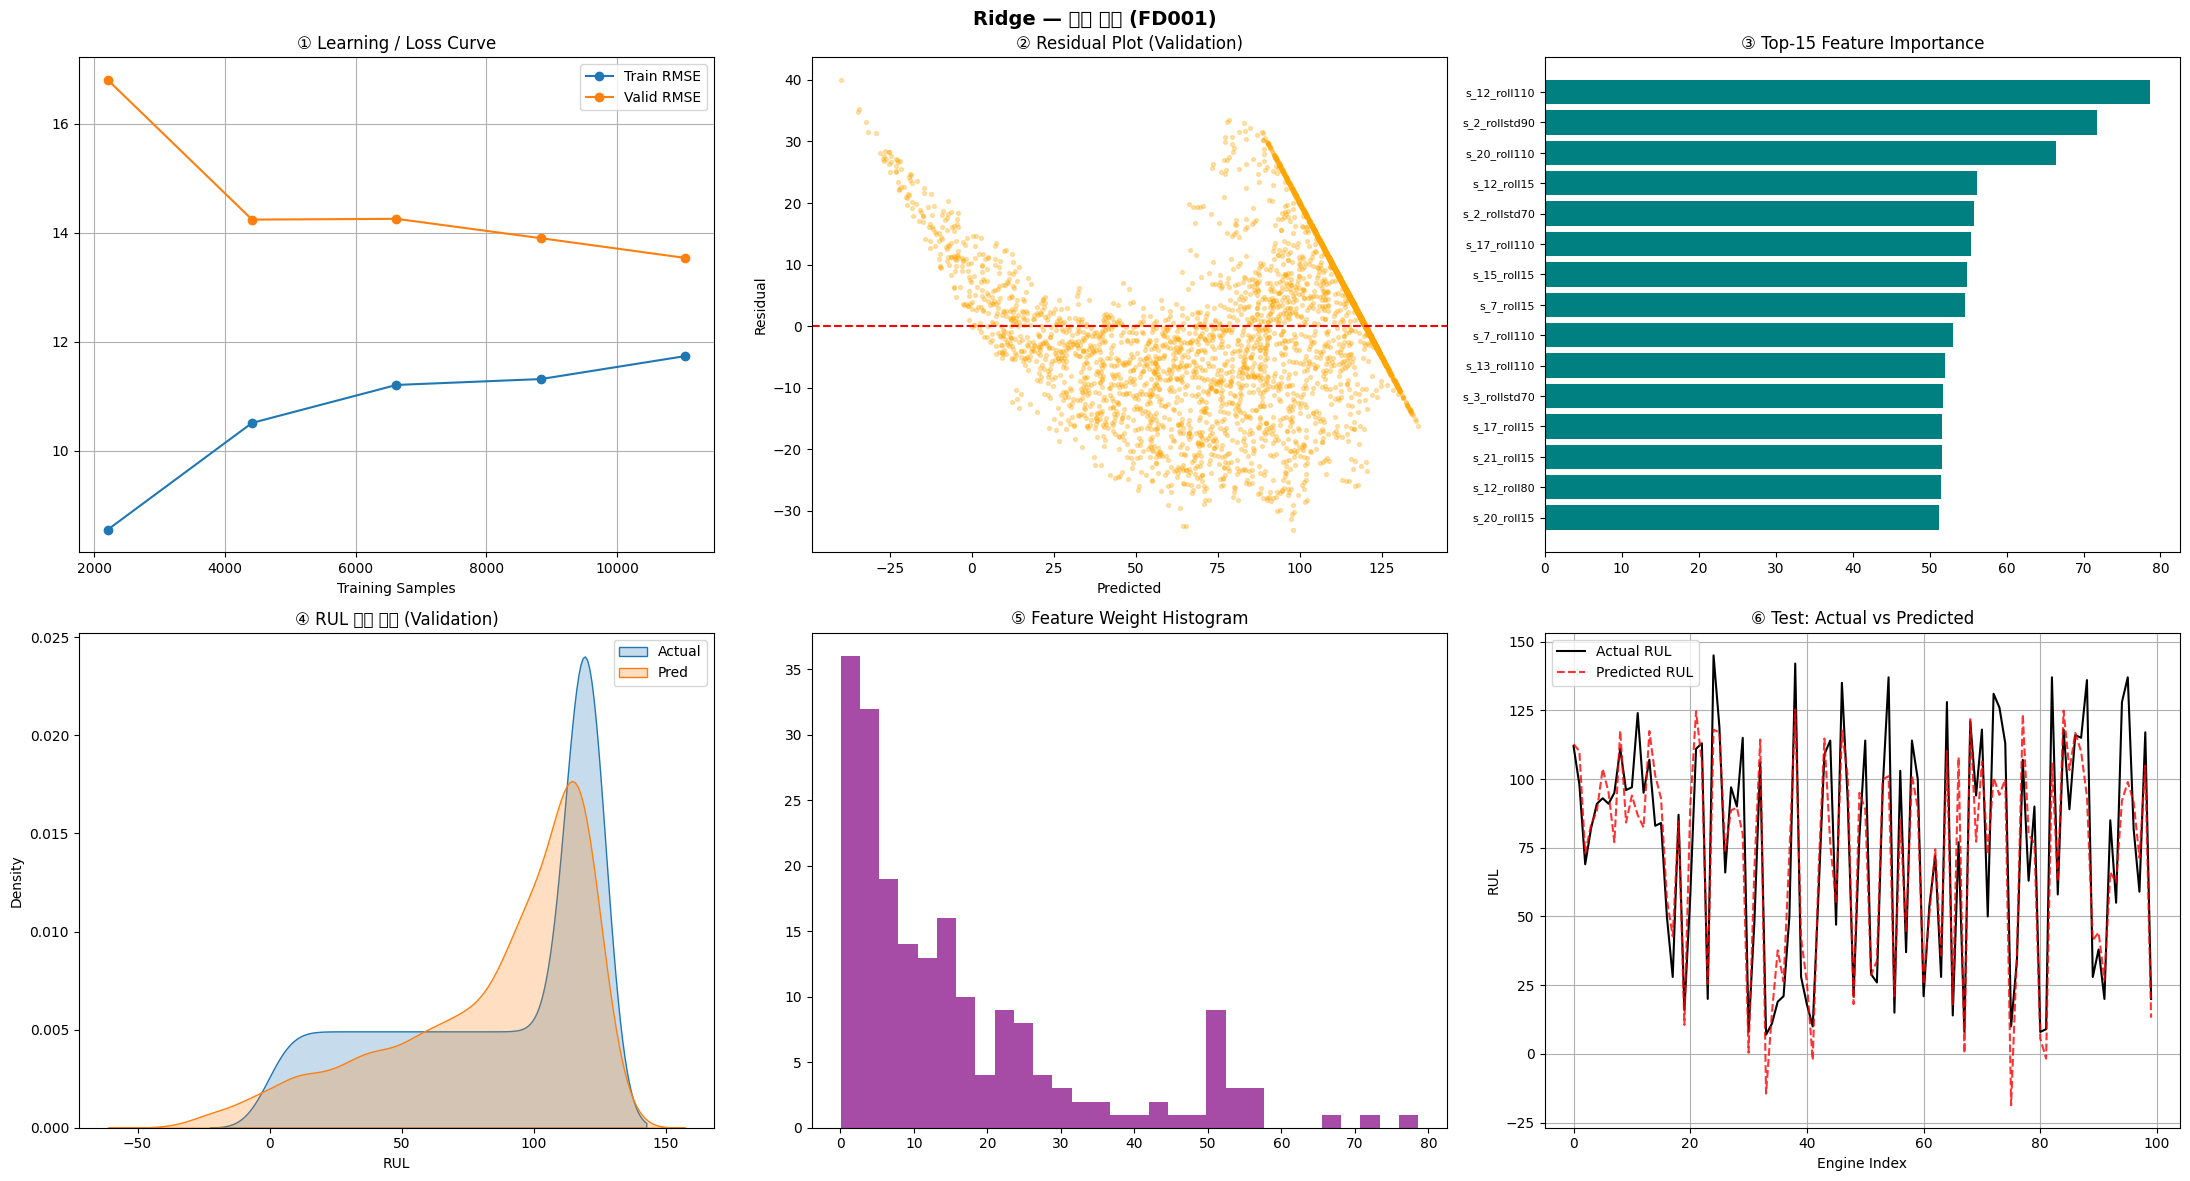

{'Train': {'RMSE': 11.286732766109326,
  'MAE': 8.297022182413977,
  'R2': 0.9197484885615418,
  'NASA_Score': 30013.141439864754},
 'Valid': {'RMSE': 11.389904305298218,
  'MAE': 8.394451755820795,
  'R2': 0.9185723308659968,
  'NASA_Score': 7451.573797211253},
 'Test': {'RMSE': 16.08392670716109,
  'MAE': 12.433548857829068,
  'R2': 0.850195580302456,
  'NASA_Score': 348.1774453717268}}

In [10]:
# ── Ridge ─────────────────────────────────────────────────────────────────
ridge_params = {'alpha': 1.0, 'solver': 'auto', 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_ridge  = Ridge(**ridge_params)
model_ridge.fit(X_train, y_train)
evaluate_full_pipeline(model_ridge, 'Ridge')


 🏆 Lasso 평가 결과 (FD001)
 [Train] RMSE=13.5521 | MAE=9.9875 | R2=0.8843 | NASA=48426.7
 [Valid] RMSE=12.8788 | MAE=9.5728 | R2=0.8959 | NASA=10445.5
 [Test ] RMSE=16.8896 | MAE=13.0365 | R2=0.8348 | NASA=386.3


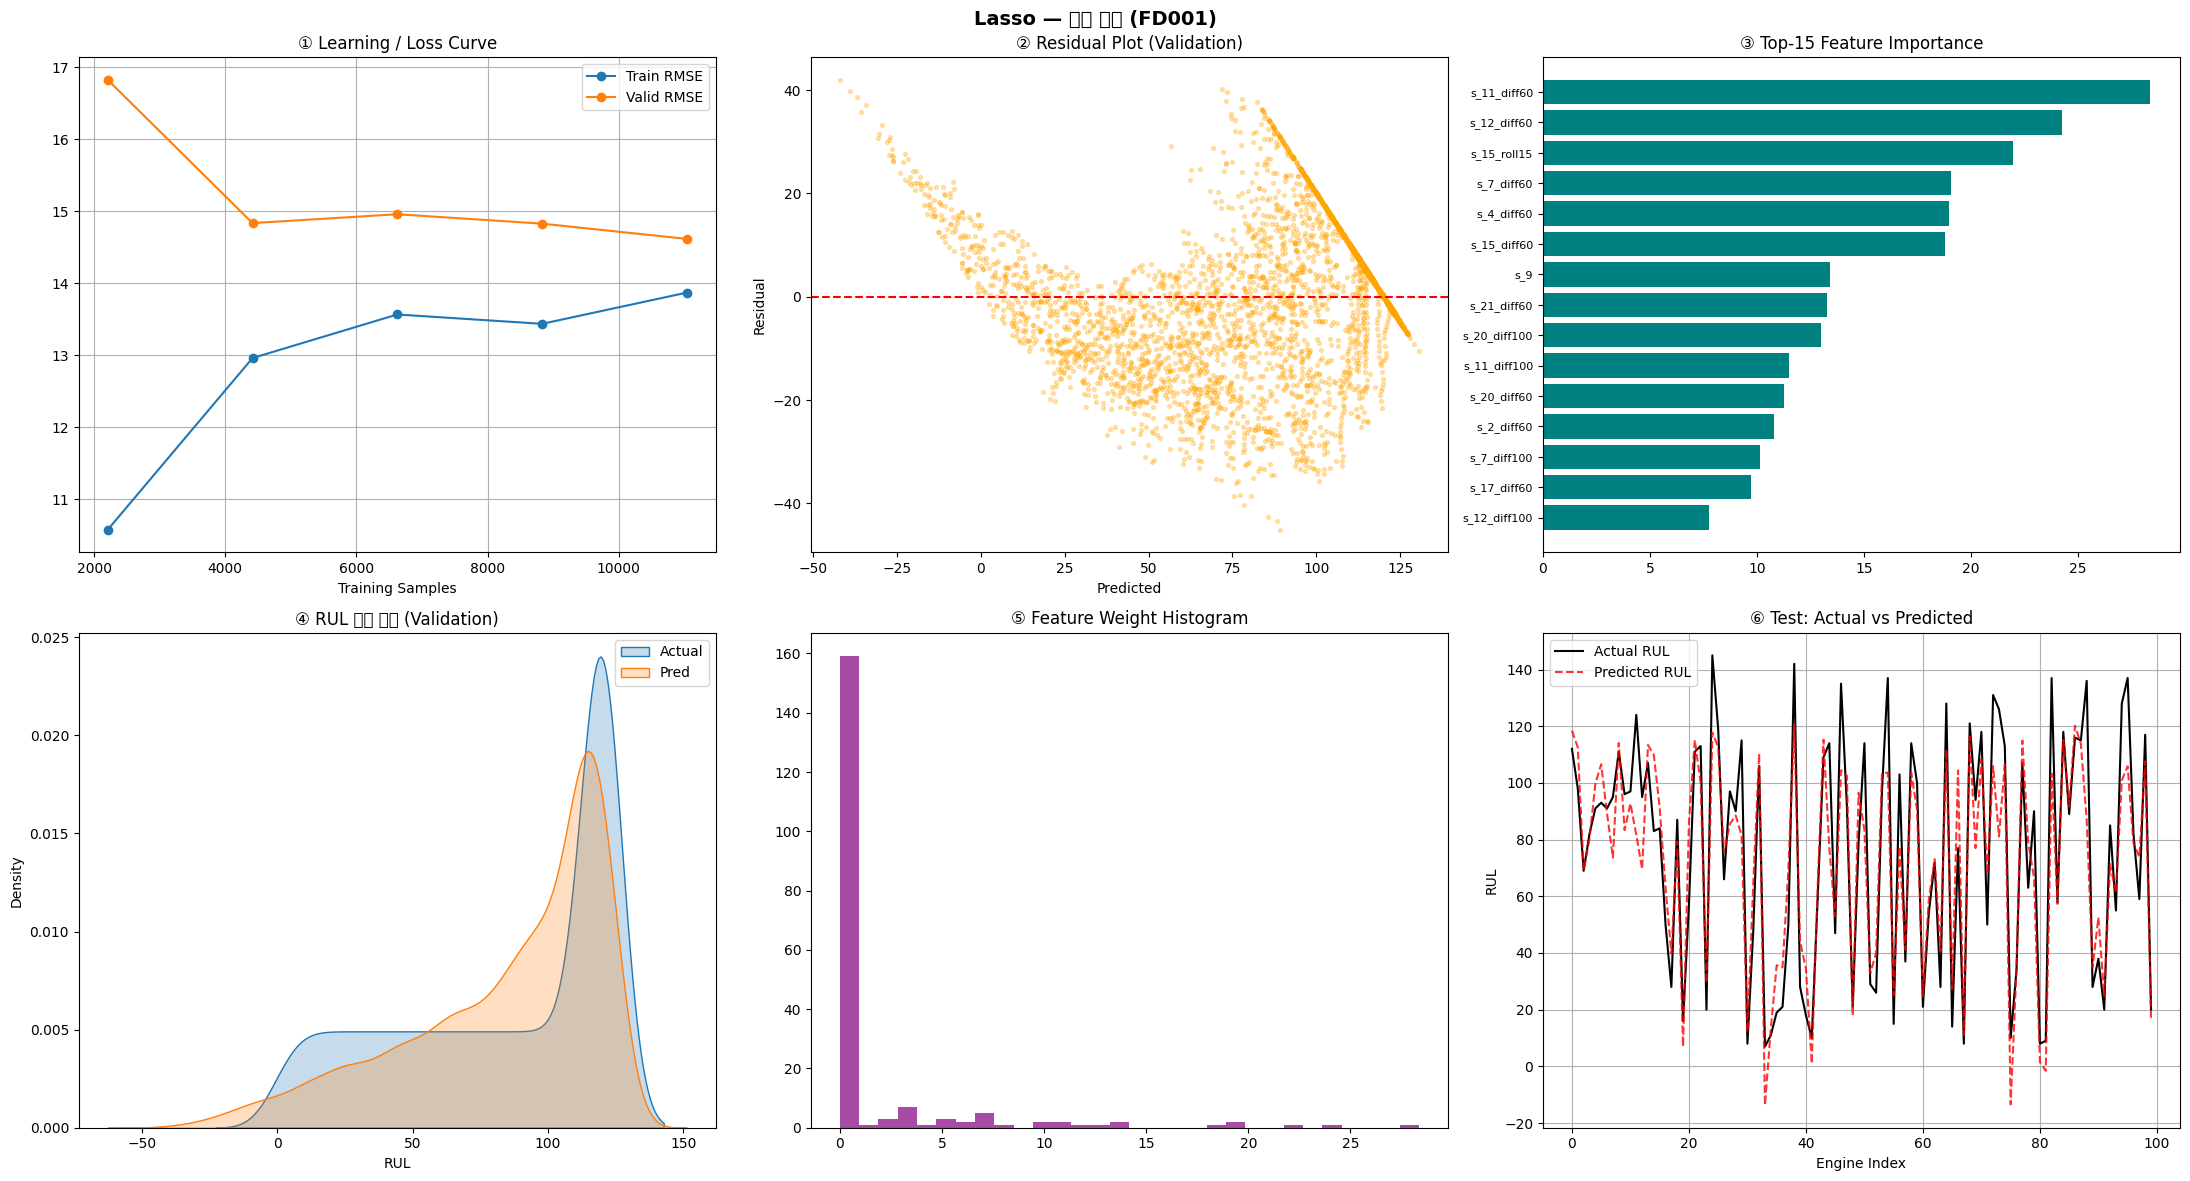

{'Train': {'RMSE': 13.552079899250552,
  'MAE': 9.987451579590871,
  'R2': 0.8843012564752292,
  'NASA_Score': 48426.67337085403},
 'Valid': {'RMSE': 12.878759708580647,
  'MAE': 9.572785546007953,
  'R2': 0.8958929996683606,
  'NASA_Score': 10445.486576933348},
 'Test': {'RMSE': 16.88963830320658,
  'MAE': 13.036514414874311,
  'R2': 0.8348109886159656,
  'NASA_Score': 386.32236695907676}}

In [11]:
# ── Lasso ─────────────────────────────────────────────────────────────────
lasso_params = {'alpha': 0.1, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_lasso  = Lasso(**lasso_params)
model_lasso.fit(X_train, y_train)
evaluate_full_pipeline(model_lasso, 'Lasso')


 🏆 ElasticNet 평가 결과 (FD001)
 [Train] RMSE=14.7516 | MAE=11.0229 | R2=0.8629 | NASA=56379.5
 [Valid] RMSE=13.7823 | MAE=10.4997 | R2=0.8808 | NASA=11346.5
 [Test ] RMSE=18.2145 | MAE=13.9881 | R2=0.8079 | NASA=473.1


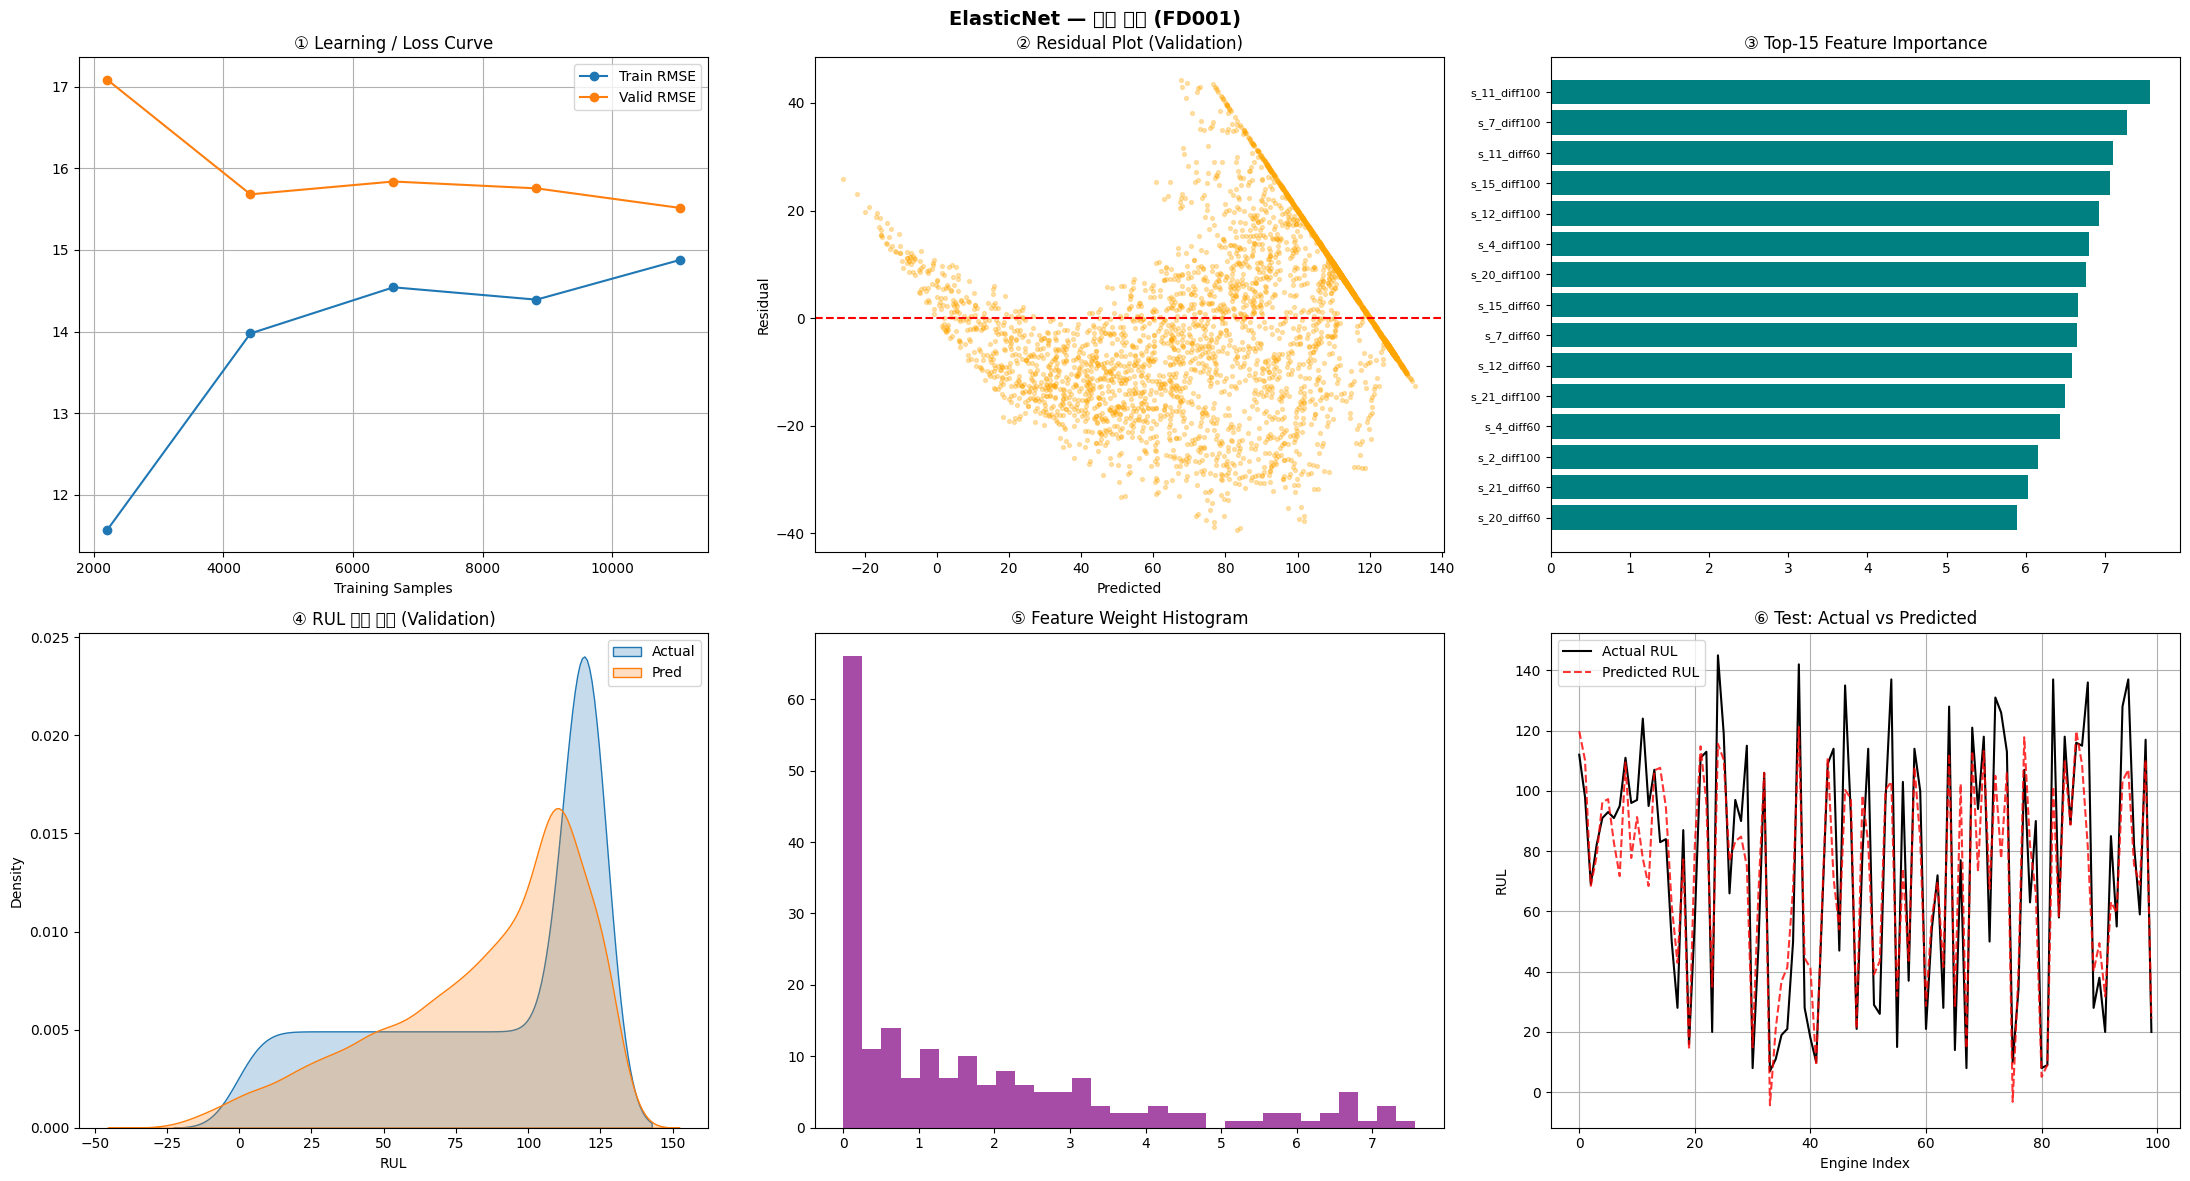

{'Train': {'RMSE': 14.751633062866743,
  'MAE': 11.022912088685633,
  'R2': 0.8629127899998236,
  'NASA_Score': 56379.54343590245},
 'Valid': {'RMSE': 13.782306952331156,
  'MAE': 10.499655574704217,
  'R2': 0.880772705555592,
  'NASA_Score': 11346.47267587779},
 'Test': {'RMSE': 18.21449901607155,
  'MAE': 13.988107133544757,
  'R2': 0.8078789652638094,
  'NASA_Score': 473.13384906839553}}

In [12]:
# ── ElasticNet ────────────────────────────────────────────────────────────
elastic_params = {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 2000, 'random_state': RANDOM_STATE}
model_elastic  = ElasticNet(**elastic_params)
model_elastic.fit(X_train, y_train)
evaluate_full_pipeline(model_elastic, 'ElasticNet')


 🏆 RandomForest 평가 결과 (FD001)
 [Train] RMSE=4.2991 | MAE=2.8614 | R2=0.9884 | NASA=6302.2
 [Valid] RMSE=9.1248 | MAE=6.1857 | R2=0.9477 | NASA=5907.2
 [Test ] RMSE=13.3902 | MAE=10.0685 | R2=0.8962 | NASA=229.6


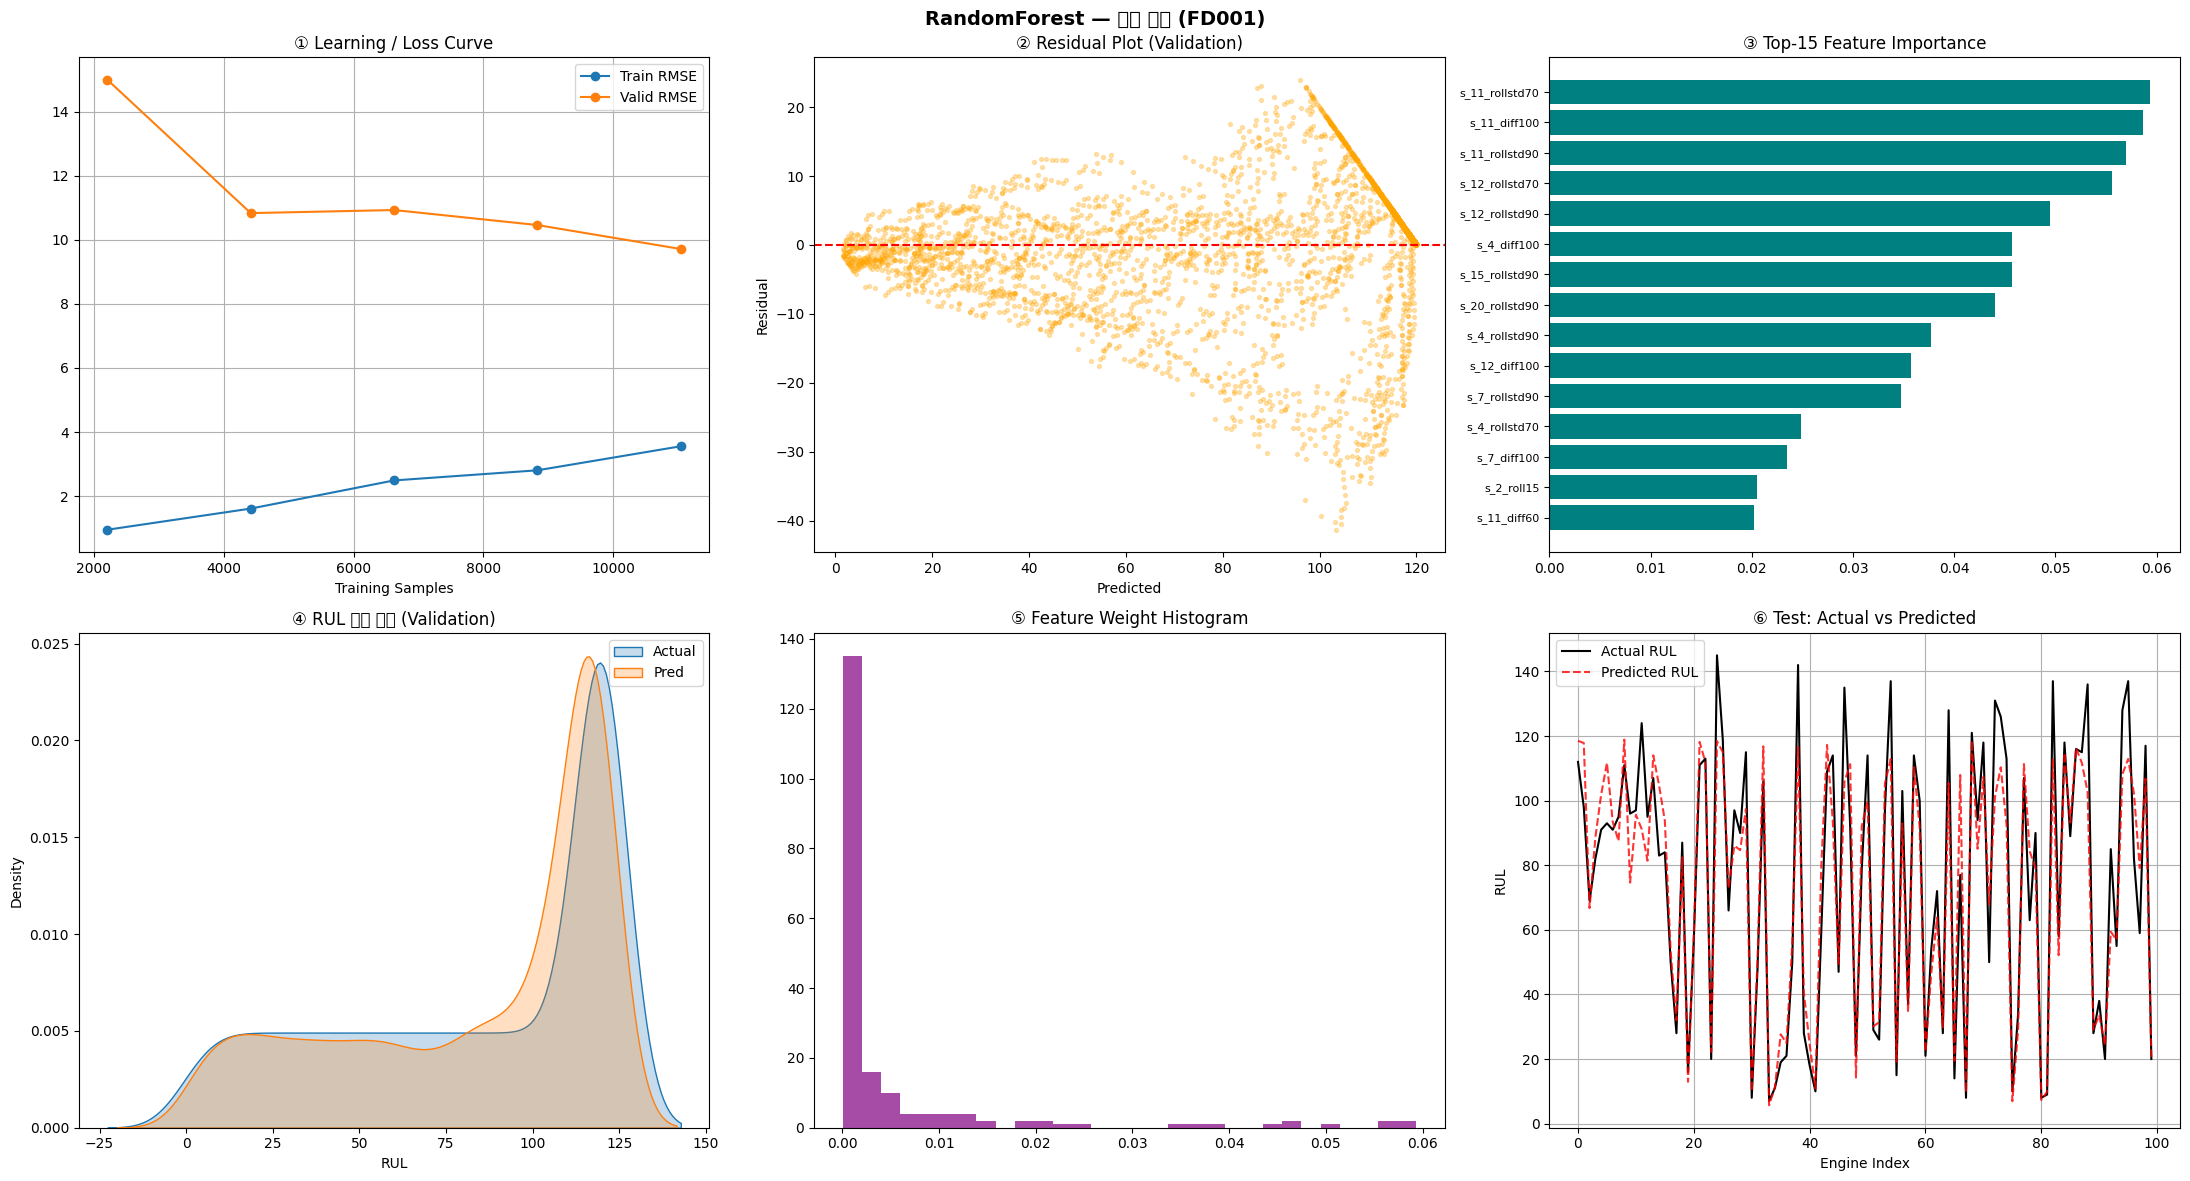

{'Train': {'RMSE': 4.299092090907898,
  'MAE': 2.861404685711409,
  'R2': 0.9883568569818775,
  'NASA_Score': 6302.202458643347},
 'Valid': {'RMSE': 9.124813801370616,
  'MAE': 6.185687944128394,
  'R2': 0.9477387401473779,
  'NASA_Score': 5907.204941539131},
 'Test': {'RMSE': 13.390221141590654,
  'MAE': 10.068521759887568,
  'R2': 0.8961716494281321,
  'NASA_Score': 229.63974713864687}}

In [13]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_params = {
    'n_estimators': 200, 'max_depth': 10,
    'min_samples_split': 5, 'min_samples_leaf': 2,
    'max_features': 'sqrt', 'n_jobs': -1, 'random_state': RANDOM_STATE
}
model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)
evaluate_full_pipeline(model_rf, 'RandomForest', is_tree=True)


 🏆 LightGBM 평가 결과 (FD001)
 [Train] RMSE=2.3492 | MAE=1.5812 | R2=0.9965 | NASA=2737.5
 [Valid] RMSE=8.9528 | MAE=5.8918 | R2=0.9497 | NASA=5764.1
 [Test ] RMSE=13.5175 | MAE=10.3149 | R2=0.8942 | NASA=237.1


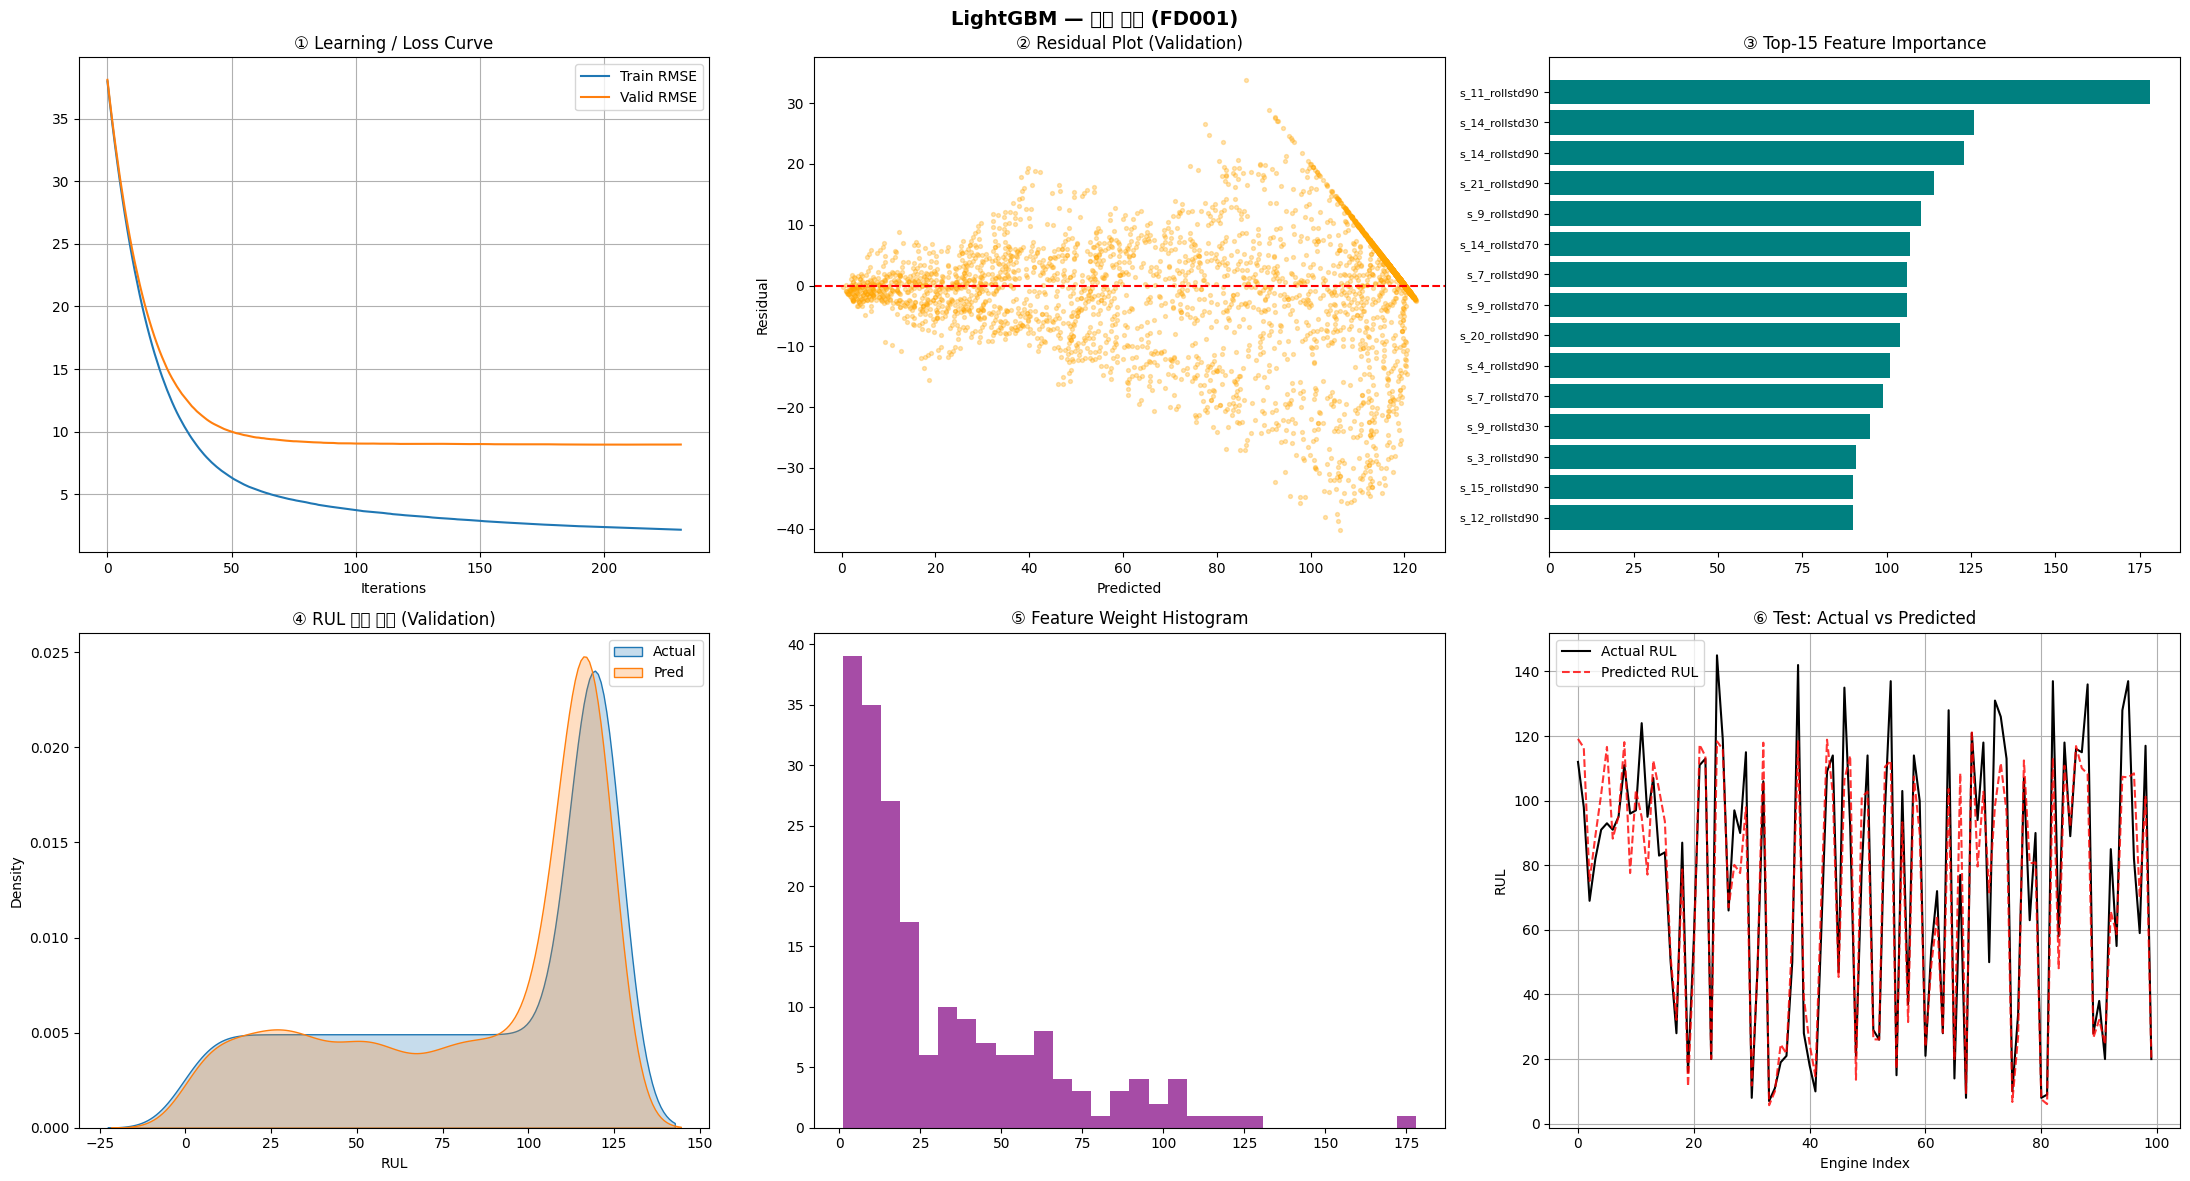

{'Train': {'RMSE': 2.3492196556774894,
  'MAE': 1.5812210491318497,
  'R2': 0.996523325858731,
  'NASA_Score': 2737.4838183276042},
 'Valid': {'RMSE': 8.952818602041532,
  'MAE': 5.891834954721452,
  'R2': 0.9496903352921798,
  'NASA_Score': 5764.14863736826},
 'Test': {'RMSE': 13.517540628640054,
  'MAE': 10.314926764537223,
  'R2': 0.8941877807988892,
  'NASA_Score': 237.13066595728546}}

In [14]:
# ── LightGBM ──────────────────────────────────────────────────────────────
lgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'num_leaves': 31,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'device': LGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1
}
model_lgb = lgb.LGBMRegressor(**lgb_params)
model_lgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

res_lgb = model_lgb.evals_result_
train_key = 'training' if 'training' in res_lgb else 'valid_0'
m_key = 'rmse' if 'rmse' in res_lgb[train_key] else list(res_lgb[train_key].keys())[0]
eval_dict_lgb = {'train': res_lgb[train_key][m_key],
                 'valid': res_lgb['valid_1'][m_key]}
evaluate_full_pipeline(model_lgb, 'LightGBM', is_tree=True,
                       is_boosting=True, eval_results=eval_dict_lgb)


 🏆 XGBoost 평가 결과 (FD001)
 [Train] RMSE=0.8748 | MAE=0.5810 | R2=0.9995 | NASA=890.2
 [Valid] RMSE=9.1919 | MAE=6.0015 | R2=0.9470 | NASA=6150.3
 [Test ] RMSE=13.6103 | MAE=10.4246 | R2=0.8927 | NASA=239.0


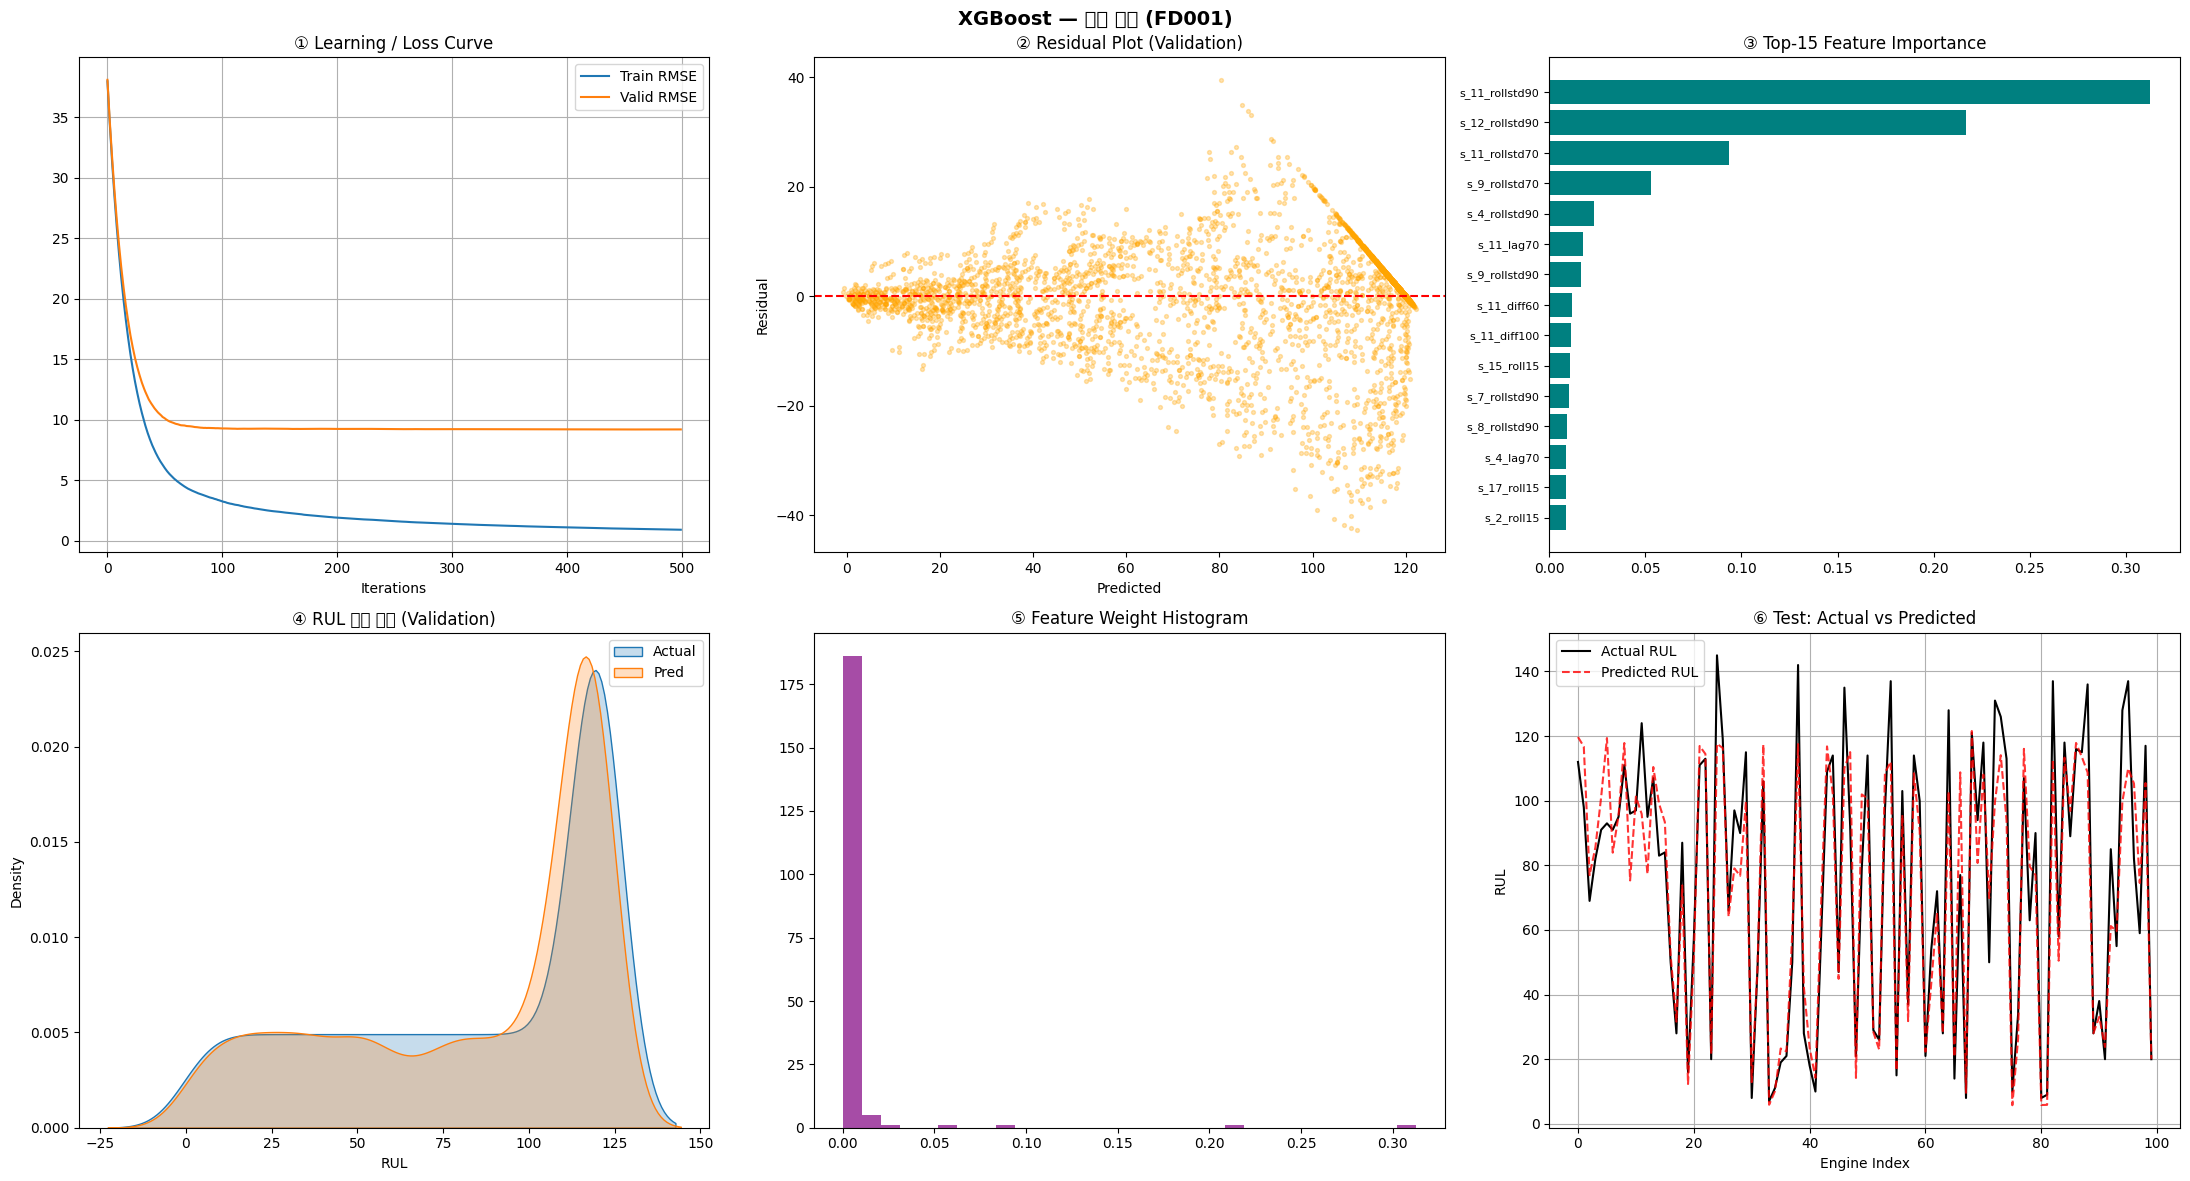

{'Train': {'RMSE': 0.874770573347051,
  'MAE': 0.5810411629574028,
  'R2': 0.9995179355936418,
  'NASA_Score': 890.1872799563016},
 'Valid': {'RMSE': 9.19188349045592,
  'MAE': 6.0014879343843575,
  'R2': 0.9469676497158303,
  'NASA_Score': 6150.275345546618},
 'Test': {'RMSE': 13.61025445710334,
  'MAE': 10.424595565795899,
  'R2': 0.8927313177630196,
  'NASA_Score': 239.00065870658136}}

In [15]:
# ── XGBoost ───────────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'tree_method': 'hist', 'device': XGB_DEVICE,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0
}
model_xgb = xgb.XGBRegressor(**xgb_params)
model_xgb.fit(X_train, y_train,
              eval_set=[(X_train, y_train),(X_val, y_val)], verbose=False)
res_xgb = model_xgb.evals_result()
eval_dict_xgb = {'train': res_xgb['validation_0']['rmse'],
                 'valid': res_xgb['validation_1']['rmse']}
evaluate_full_pipeline(model_xgb, 'XGBoost', is_tree=True,
                       is_boosting=True, eval_results=eval_dict_xgb)

In [16]:
# === 누수 진단: 예측 잔차 분석 ===
for mname, m in [('Ridge', model_ridge), ('LGBM', model_lgb), ('XGB', model_xgb)]:
    pred = np.clip(m.predict(X_test), 0, CONFIG['rul_cap'])
    d = pred - y_test
    print(f'\n[{mname}] pred: min={pred.min():.1f} max={pred.max():.1f} mean={pred.mean():.1f}')
    print(f'         잔차 음수(보수적): {(d<0).mean():.1%}')
    print(f'         잔차 양수(낙관적): {(d>0).mean():.1%}')
    print(f'         |d| 평균: {np.abs(d).mean():.2f}')

# 음수 비율이 70% 이상이면 정상적으로 잘 나온 거. 50:50인데 NASA가 200대면 누수


[Ridge] pred: min=0.0 max=120.0 mean=73.2
         잔차 음수(보수적): 48.0%
         잔차 양수(낙관적): 52.0%
         |d| 평균: 12.43

[LGBM] pred: min=5.7 max=120.0 mean=73.3
         잔차 음수(보수적): 52.0%
         잔차 양수(낙관적): 48.0%
         |d| 평균: 10.31

[XGB] pred: min=5.8 max=120.0 mean=73.2
         잔차 음수(보수적): 52.0%
         잔차 양수(낙관적): 48.0%
         |d| 평균: 10.42
